# Hellinger distance

The Hellinger distnace for two discrete distributions $p = (p_0, \dots , p_n)$ and $q = (q_0, \dots, q_n) $ is defined as follows:

$$ H(p, q) = \frac{1}{\sqrt{2}} \sqrt{\sum_i^n (\sqrt{p_i} - \sqrt{q_i})^2}$$

In [107]:
import numpy as np
from scipy.stats import dirichlet
import matplotlib.pyplot as plt
import math
import time

In [108]:
# some test distributions
x = [0, .1, .5, .4]
y = [.3, .6, .02, .08]

a = [1, 0]
b = [0, 1]

## 1. Original version

In [110]:
def hellinger(p, q):
    """Hellinger distance between two discrete distributions.
       In pure Python.
       Original, ugly version.
    """
    return sum([(math.sqrt(t[0])-math.sqrt(t[1]))*(math.sqrt(t[0])-math.sqrt(t[1]))\
                for t in zip(p,q)])/math.sqrt(2.)

Despite from being ugly, the version `hellinger(p, q)` ommits the square root of the sum. This is a legal thing to, but notice that in this case the maximum distance of $p$ and $q$ is $\sqrt{2}$ and not 1.

In [111]:
hellinger(a, a)

0.0

In [109]:
hellinger(a, b)

1.414213562373095

## 2. Some improvements

In [112]:
def hellinger2(p, q):
    """Hellinger distance between two discrete distributions. 
       In pure Python.
       Some improvements.
    """
    return math.sqrt(sum([ (math.sqrt(p_i) - math.sqrt(q_i))**2 for p_i, q_i in zip(p, q) ]) / 2)

In `hellinger2(p, q)` I replace the the variable `t` with `p_i` and `q_i` for better readability. I further utilized the `**` in order to calculate the square, since it is much faster than calculating the square root for each `p_i` and `q_i` two times. The line continuation operator `\` is needless here, so it can be omitted. Since $\sqrt{\frac{x}{y}} = \frac{\sqrt{x}}{\sqrt{y}}$, we save one square root operation by first deviding the sum by 2 and than taking the square root of the result.

## 3. Without list comprehension

In [9]:
def hellinger_explicit(p, q):
    """Hellinger distance between two discrete distributions.
       In pure Python.
       Same as hellinger2 but without list comprehension
    """
    list_of_squares = []
    for p_i, q_i in zip(p, q):

        # caluclate the square of the difference of ith distr elements
        s = (math.sqrt(p_i) - math.sqrt(q_i)) ** 2
        
        # append 
        list_of_squares.append(s)
    
    # calculate sum of squares
    sosq = sum(list_of_squares)    
    
    return math.sqrt(sosq / 2)

## 4. Further improvements

In [113]:
def hellinger_dot(p, q):
    """Hellinger distance between two discrete distributions. 
       Using numpy.
       For Python >= 3.5 only"""
    z = np.sqrt(p) - np.sqrt(q)
    return np.sqrt(z @ z / 2)

The sum of squares of the elements of some vector is nothing else but a dot product. Thus, asuming `p` and `q` to be numpy arrays, we can utilize matrix product operator `@` from Python >= 3.5, which very much simplifies the code.

## 5. Need for speed

In [100]:
def hellinger_fast(p, q):
    """Hellinger distance between two discrete distributions.
       In pure Python.
       Fastest version.
    """
    return sum([ (math.sqrt(p_i) - math.sqrt(q_i))**2 for p_i, q_i in zip(p,q) ])

We can slightly improve the performance of the pure python versions. Notice that, as in `hellinger(p, q)` on can ommit the sqaure root since it is a monoonic function. On could also ommit the factor $\frac{1}{\sqrt{2}}$ because it only scales the sum. This, however, that for two maximally different distribution, maximum value of `hellinger_fast(p, q)` is two.  

In [114]:
hellinger_fast(a, a)

0.0

In [118]:
hellinger_fast(a, b)

2.0

## 6. Time it!

In [36]:
%timeit hellinger(x, y)

3.28 µs ± 41.9 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [37]:
%timeit hellinger2(x, y)

2.25 µs ± 43.7 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [38]:
%timeit hellinger_explicit(x, y)

2.53 µs ± 45.8 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [39]:
%timeit hellinger_dot(x, y)

6.75 µs ± 93.5 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


In [101]:
%timeit hellinger_fast(x, y)

2.18 µs ± 36.1 ns per loop (mean ± std. dev. of 7 runs, 100000 loops each)


## 7. Performance test with graphical output

In [119]:
funs = {'hellinger':hellinger, 
        'hellinger2':hellinger2,
        'hellinger_explicit':hellinger_explicit, 
        'hellinger_fast':hellinger_fast,
        'hellinger_dot':hellinger_dot}

In [121]:
MAX_ELEM = 1000
MAX_RUNS = 100

benchmark = np.empty((MAX_ELEM, len(funs), MAX_RUNS))

for i in range(MAX_ELEM):
    p, q = dirichlet.rvs([1]*(i+1), size=2)
    
    for j, fun in enumerate(funs.values()):
        
        for k in range(MAX_RUNS):
        
            start = time.time()
            _ = fun(p, q)
            benchmark[i, j, k] = time.time() - start

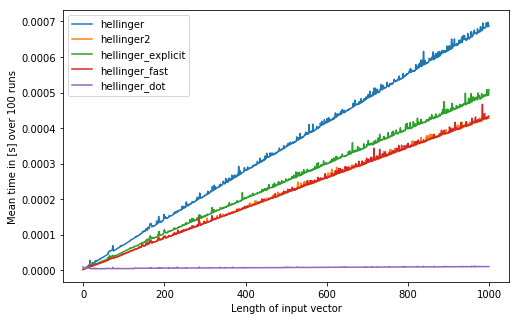

In [122]:
fig, ax = plt.subplots(1,1, figsize=(8, 5))
ax.plot(benchmark.mean(axis=2))            
ax.set_xlabel('Length of input vector')
ax.set_ylabel('Mean time in [s] over {} runs'.format(MAX_RUNS))
ax.legend(list(funs.keys()))
plt.show()

The original function scales worst. There is no big difference between `hellinger2` and `hellinger_fast` since they only differ by of division. `hellinger_explicit` scales worse since explicit for loops are always slower then list comprehensions. `hellinger_dot` outpreforms the previous functions, since the for loop could be ommitted.

Thus, for discrete distribution less then twelve entries the best choice is `hellinger2`. For distributions with more entries one should use the `hellinger_dot`. 